# EDA Notebook

## 1. Importar librerías necesarias
Importar pandas, numpy, matplotlib y seaborn para el análisis y visualización de datos.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Cargar el archivo CSV
Solicitar al usuario la ruta del archivo .csv y cargarlo en un DataFrame de pandas.

In [10]:
file_path = "../data/raw/netflix_titles.csv"

df = pd.read_csv(file_path)

## 3. Visualizar las primeras filas del dataset
Mostrar las primeras filas del DataFrame usando head() para obtener una vista general de los datos.

In [11]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 4. Explorar información general del dataset
Utilizar info() y shape para mostrar información sobre el número de filas, columnas y tipos de datos.

In [12]:
df.info()
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB
Número de filas: 8807
Número de columnas: 12


## 5. Describir variables numéricas y categóricas
Usar describe() para variables numéricas y value_counts() para variables categóricas.

In [13]:
df['type'].value_counts()

df['rating'].value_counts()

df['country'].value_counts().head(10)

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

## 6. Visualizar valores nulos y duplicados
Identificar y visualizar la cantidad de valores nulos y filas duplicadas en el dataset.

In [14]:
# Null values
df.isnull().sum()

# Duplicated rows
df.duplicated().sum()

df.drop_duplicates(inplace=True)

## 7. Análisis univariado de variables numéricas
Realizar histogramas y boxplots para analizar la distribución de las variables numéricas.

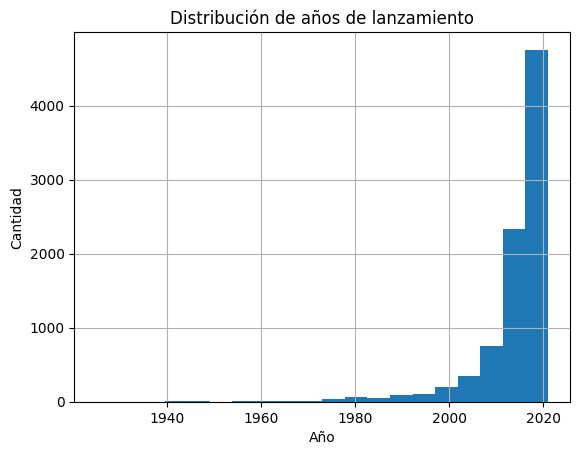

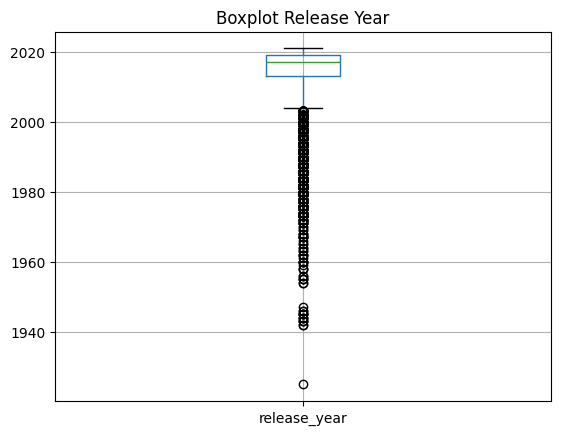

In [15]:
df['release_year'].hist(bins=20)

plt.title("Distribución de años de lanzamiento")
plt.xlabel("Año")
plt.ylabel("Cantidad")
plt.show()

df.boxplot(column='release_year')

plt.title("Boxplot Release Year")
plt.show()

## 8. Análisis univariado de variables categóricas
Realizar gráficos de barras para analizar la frecuencia de las variables categóricas.

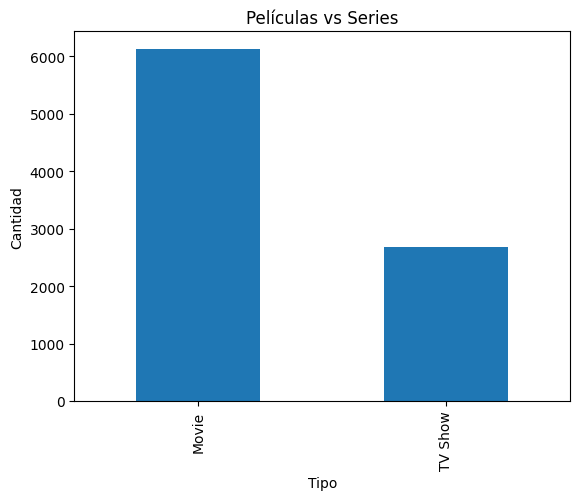

In [16]:
df['type'].value_counts().plot(kind='bar')

plt.title("Películas vs Series")
plt.xlabel("Tipo")
plt.ylabel("Cantidad")
plt.show()

## 9. Análisis bivariado entre variables
Explorar relaciones entre variables numéricas y categóricas mediante scatterplots y tablas cruzadas.

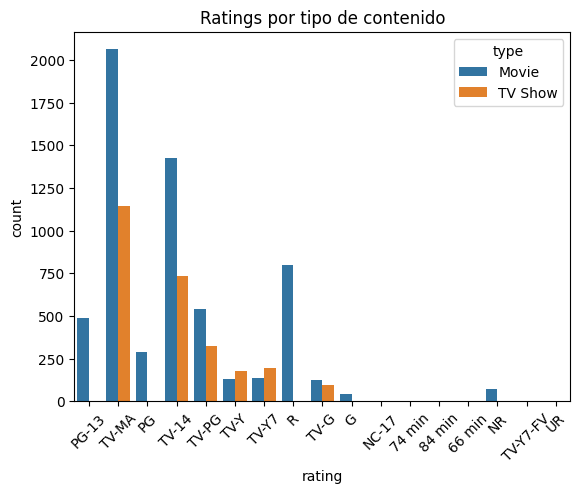

In [17]:
sns.countplot(x='rating', hue='type', data=df)

plt.xticks(rotation=45)
plt.title("Ratings por tipo de contenido")
plt.show()

## 10. Visualización de correlaciones
Calcular y visualizar la matriz de correlación entre variables numéricas usando un heatmap.

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\maria\AppData\Local\Temp\ipykernel_5452\2939936104.py:3: SyntaxWarning: invalid escape sequence '\d'
  df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)


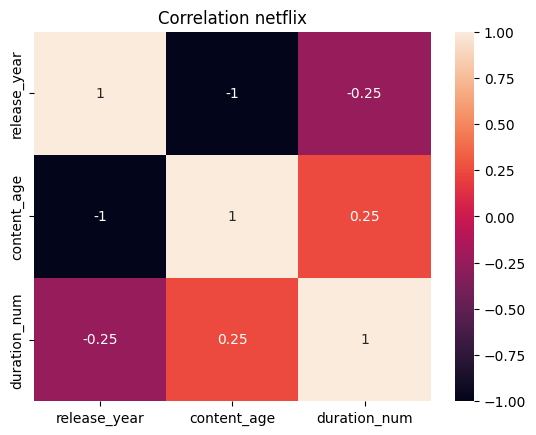

In [18]:
df['content_age'] = 2026 - df['release_year']

df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)
corr = df[['release_year', 'content_age', 'duration_num']].corr()

sns.heatmap(corr, annot=True)

plt.title("Correlation netflix")
plt.show()


## Conclusiones

- Netflix aumentó considerablemente su catálogo después de 2015.
- Las películas representan la mayor parte del contenido.
- Estados Unidos domina la producción del catálogo.
